In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, freqz
from src.measure_ir import *
import soundfile as sf
import librosa

In [34]:
fs=96_000


In [27]:
data = np.load(r".\data\cancelled.npz")

cancel    = data["cancel"]
ref  = data["ref"]
no_cancel = data["no_cancel"]
n_repeats  = data["n_repeats"]


irs = np.load(r".\data\current_irs.npz")
error_ir, ref_ir = align_irs_by_distance(irs["error_ir"], irs["ref_ir"], distance_cm=4.5, ir_len=256, fs=fs)

In [35]:
arthur, sr = sf.read('data/arthur_clip_48k.wav')
arthur_96 = librosa.resample(arthur, orig_sr=sr, target_sr=fs)
source = np.tile(arthur_96, n_repeats)

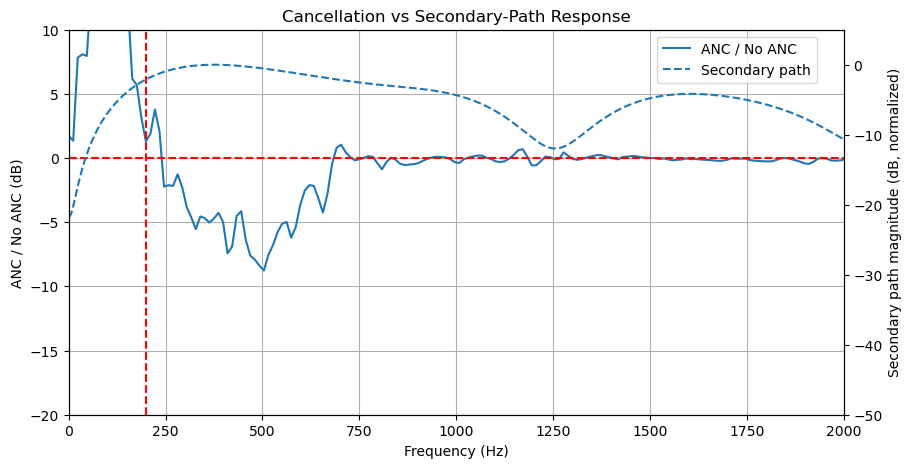

In [29]:


# -------------------------
# ANC / No-ANC spectrum
# -------------------------

f, P_cancel = welch(cancel, fs=fs, nperseg=8192)
_, P_no_cancel = welch(no_cancel, fs=fs, nperseg=8192)

reduction_db = 10 * np.log10(
    (P_cancel + 1e-30) /
    (P_no_cancel + 1e-30)
)

# -------------------------
# Secondary-path response
# -------------------------

f_ir, H = freqz(error_ir, worN=8192, fs=fs)

H_db = 20 * np.log10(np.abs(H) + 1e-30)

# Normalize it because right now we're interested
# primarily in the SHAPE of the response
H_db -= np.max(H_db)

# -------------------------
# Plot
# -------------------------

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(f, reduction_db, label="ANC / No ANC")
ax1.axhline(0, linestyle="--", c="r")
ax1.axvline(200, linestyle="--", c='r')
ax1.set_xlim(0, 2000)
ax1.set_ylim(-20, 10)

ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("ANC / No ANC (dB)")
ax1.grid()

ax2 = ax1.twinx()

ax2.plot(
    f_ir,
    H_db,
    linestyle="--",
    label="Secondary path"
)

ax2.set_ylabel("Secondary path magnitude (dB, normalized)")
ax2.set_ylim(-50, 5)

fig.legend(
    loc="upper right",
    bbox_to_anchor=(0.88, 0.88)
)

plt.title("Cancellation vs Secondary-Path Response")
plt.show()

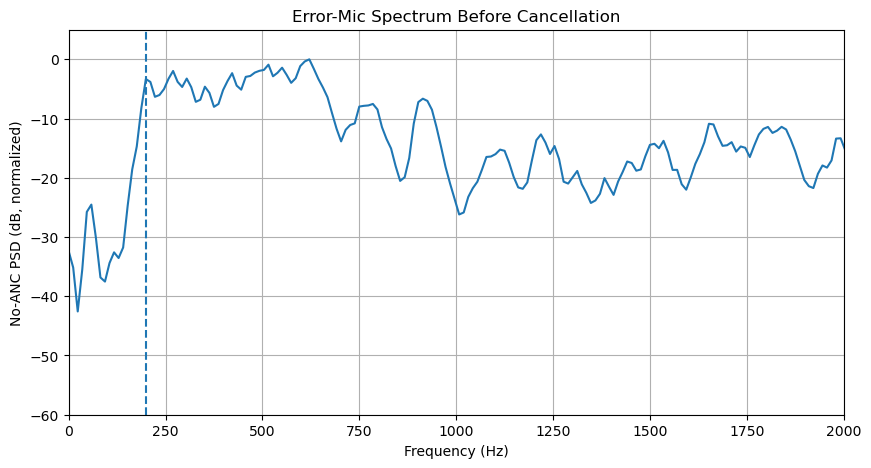

In [30]:
P_no_cancel_db = 10 * np.log10(P_no_cancel + 1e-30)
P_no_cancel_db -= np.max(P_no_cancel_db)

plt.figure(figsize=(10, 5))

plt.plot(f, P_no_cancel_db)

plt.xlim(0, 2000)
plt.ylim(-60, 5)

plt.axvline(200, linestyle="--")

plt.xlabel("Frequency (Hz)")
plt.ylabel("No-ANC PSD (dB, normalized)")
plt.title("Error-Mic Spectrum Before Cancellation")
plt.grid()

plt.show()

In [37]:
import numpy as np
from scipy.signal import correlate, correlation_lags

# Optional: remove DC first
x = source - np.mean(source)
y = no_cancel - np.mean(no_cancel)

corr = correlate(y, x, mode="full", method="fft")
lags = correlation_lags(len(y), len(x), mode="full")

lag = lags[np.argmax(np.abs(corr))]

print("Estimated lag:", lag, "samples")
print("Estimated lag:", 1000 * lag / fs, "ms")

Estimated lag: 35418 samples
Estimated lag: 368.9375 ms


 -919919 samples   -9582.490 ms   corr=1.004e+03
 -442335 samples   -4607.656 ms   corr=-1.011e+03
 -442251 samples   -4606.781 ms   corr=1.337e+03
   35333 samples    368.052 ms   corr=-1.260e+03
   35418 samples    368.938 ms   corr=1.665e+03
  513002 samples   5343.771 ms   corr=-1.008e+03
  513086 samples   5344.646 ms   corr=1.331e+03
  990755 samples   10320.365 ms   corr=9.970e+02


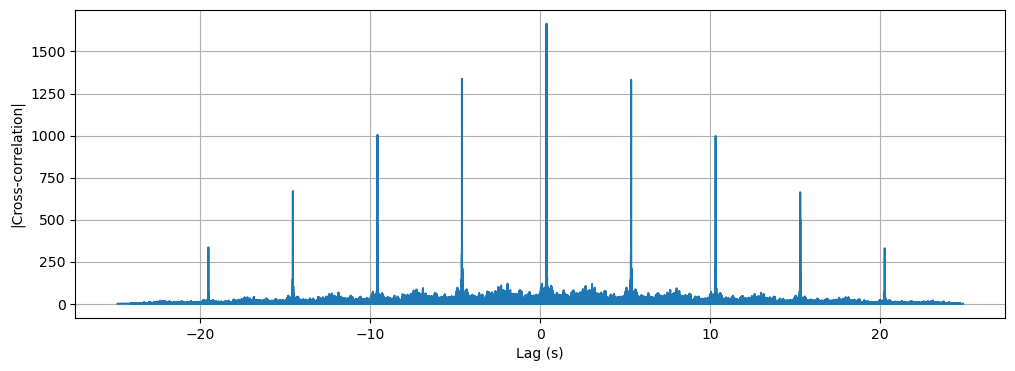

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, correlation_lags, find_peaks

x = source - np.mean(source)
y = no_cancel - np.mean(no_cancel)

corr = correlate(y, x, mode="full", method="fft")
lags = correlation_lags(len(y), len(x), mode="full")

# Find strong correlation peaks
peaks, props = find_peaks(
    np.abs(corr),
    height=0.5 * np.max(np.abs(corr)),
)

for p in peaks:
    print(
        f"{lags[p]:8d} samples   "
        f"{1000 * lags[p] / fs:8.3f} ms   "
        f"corr={corr[p]:.3e}"
    )

plt.figure(figsize=(12, 4))
plt.plot(lags / fs, np.abs(corr))
plt.xlabel("Lag (s)")
plt.ylabel("|Cross-correlation|")
plt.grid()
plt.show()

In [40]:
lag = 35418

source_aligned = source[:-lag]
no_cancel_aligned = no_cancel[lag:]

N = min(len(source_aligned), len(no_cancel_aligned))

source_aligned = source_aligned[:N]
no_cancel_aligned = no_cancel_aligned[:N]

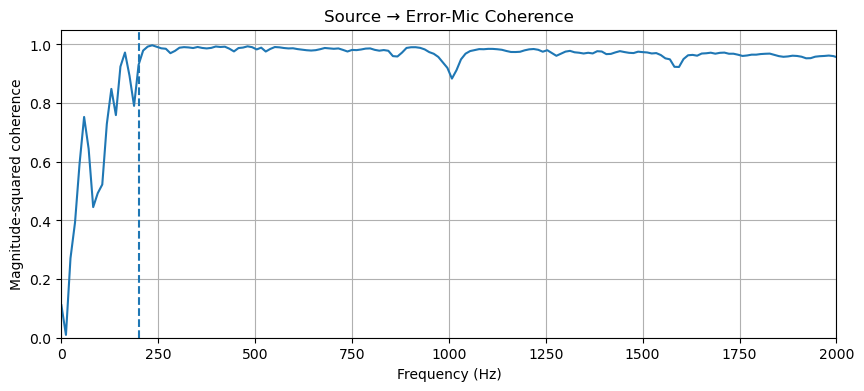

In [41]:
from scipy.signal import coherence

f_coh, coh = coherence(
    source_aligned,
    no_cancel_aligned,
    fs=fs,
    nperseg=8192,
)

plt.figure(figsize=(10, 4))
plt.plot(f_coh, coh)

plt.axvline(200, linestyle="--")
plt.xlim(0, 2000)
plt.ylim(0, 1.05)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude-squared coherence")
plt.title("Source → Error-Mic Coherence")
plt.grid()
plt.show()

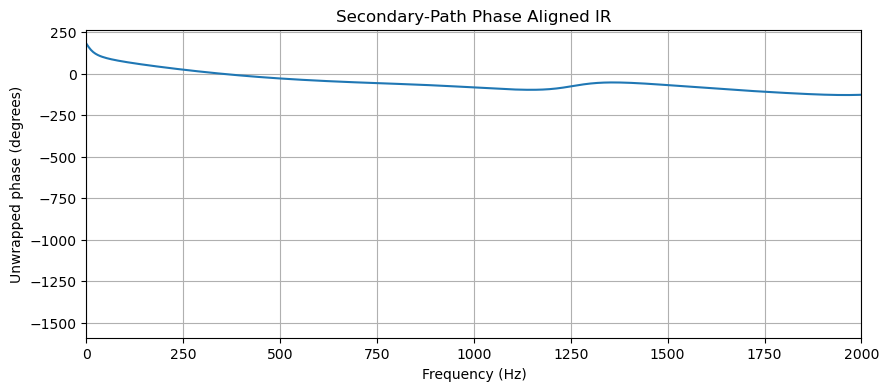

In [44]:

N = 16384

H = np.fft.rfft(error_ir, n=N)
f = np.fft.rfftfreq(N, 1/fs)

phase = np.unwrap(np.angle(H))

plt.figure(figsize=(10, 4))
plt.plot(f, np.degrees(phase))

plt.xlim(0, 2000)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Unwrapped phase (degrees)")
plt.title("Secondary-Path Phase Aligned IR")
plt.grid()

plt.show()

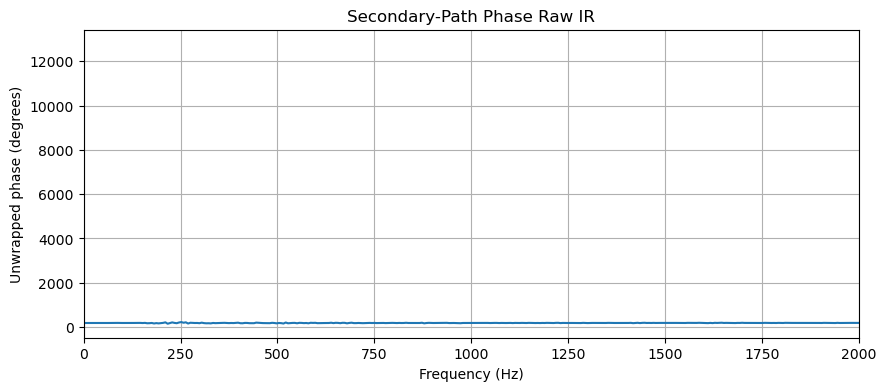

In [45]:

N = 16384

H = np.fft.rfft(irs["error_ir"], n=N)
f = np.fft.rfftfreq(N, 1/fs)

phase = np.unwrap(np.angle(H))

plt.figure(figsize=(10, 4))
plt.plot(f, np.degrees(phase))

plt.xlim(0, 2000)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Unwrapped phase (degrees)")
plt.title("Secondary-Path Phase Raw IR")
plt.grid()

plt.show()

In [46]:
peak = np.argmax(np.abs(error_ir))

print("IR peak:", peak, "samples")
print("IR peak delay:", peak / fs * 1000, "ms")

IR peak: 13 samples
IR peak delay: 0.13541666666666666 ms
